# Medidas de localización

En esta parte calculamos las medidas de localización para la edad de primera unión y el número de hijos.

In [1]:
from pathlib import Path
import sys
import os
import tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "endireh-matplotlib"))
PROYECTO = Path.cwd().resolve()
if PROYECTO.name == "notebooks":
    PROYECTO = PROYECTO.parent
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))
import polars as pl
from IPython.display import display, Image
from config.rutas import ARCHIVO_ENDIREH_PROCESADO, RUTA_FIGURAS
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_rows(40)
pl.Config.set_float_precision(4)
df = pl.read_parquet(ARCHIVO_ENDIREH_PROCESADO)
print(f"Registros: {df.height:,}, columnas: {df.width}, Polars {pl.__version__}")


Registros: 105,715, columnas: 31, Polars 1.44.2


## Cálculos

Calculamos la media simple y ponderada, la mediana simple y ponderada, la moda y los cuantiles. Usamos el factor de expansión para la media y la mediana ponderadas. En la edad solo tomamos los registros que tienen dato. El número de hijos incluye los valores que se rellenaron con cero en la práctica 3.

Para la mediana ponderada ordenamos los valores y sumamos sus pesos hasta llegar al 50% del total. Tomamos el primer valor que alcanza ese porcentaje.

In [2]:
from src.analysis.medidas_descriptivas import medidas_localizacion
localizacion = medidas_localizacion(df)
display(localizacion)

variable,n_validos,media_simple,media_ponderada,mediana_q2,mediana_ponderada,moda,p10,q1,q3,p90
str,i64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""edad_primer_union""",9951,19.9673,19.7360,18.0000,17.0000,"""10""",10.0000,12.0000,25.0000,34.0000
"""num_hijos""",105715,2.0597,1.8539,3.0000,1.0000,"""3""",0.0000,1.0000,3.0000,4.0000


## Interpretación

**Edad de primera unión:** hay 9,951 datos válidos. La media simple es 19.97 años y la ponderada es 19.74. La mediana simple es 18 y la ponderada es 17.

**Número de hijos:** hay 105,715 registros. La media simple es 2.06 y la ponderada es 1.85. La mediana simple es 3 y la ponderada es 1.

Falta la edad en el 90.59% de los registros, así que esta parte del análisis tiene esa limitación. Además, 19,231 valores de hijos se rellenaron con cero. Para revisar cómo afecta esa decisión podríamos comparar los resultados con los datos que sí estaban completos.

In [3]:
from src.visualization.eda import configurar_estilo, grafica_edad, grafica_hijos
configurar_estilo()
grafica_edad(df)
grafica_hijos(df)

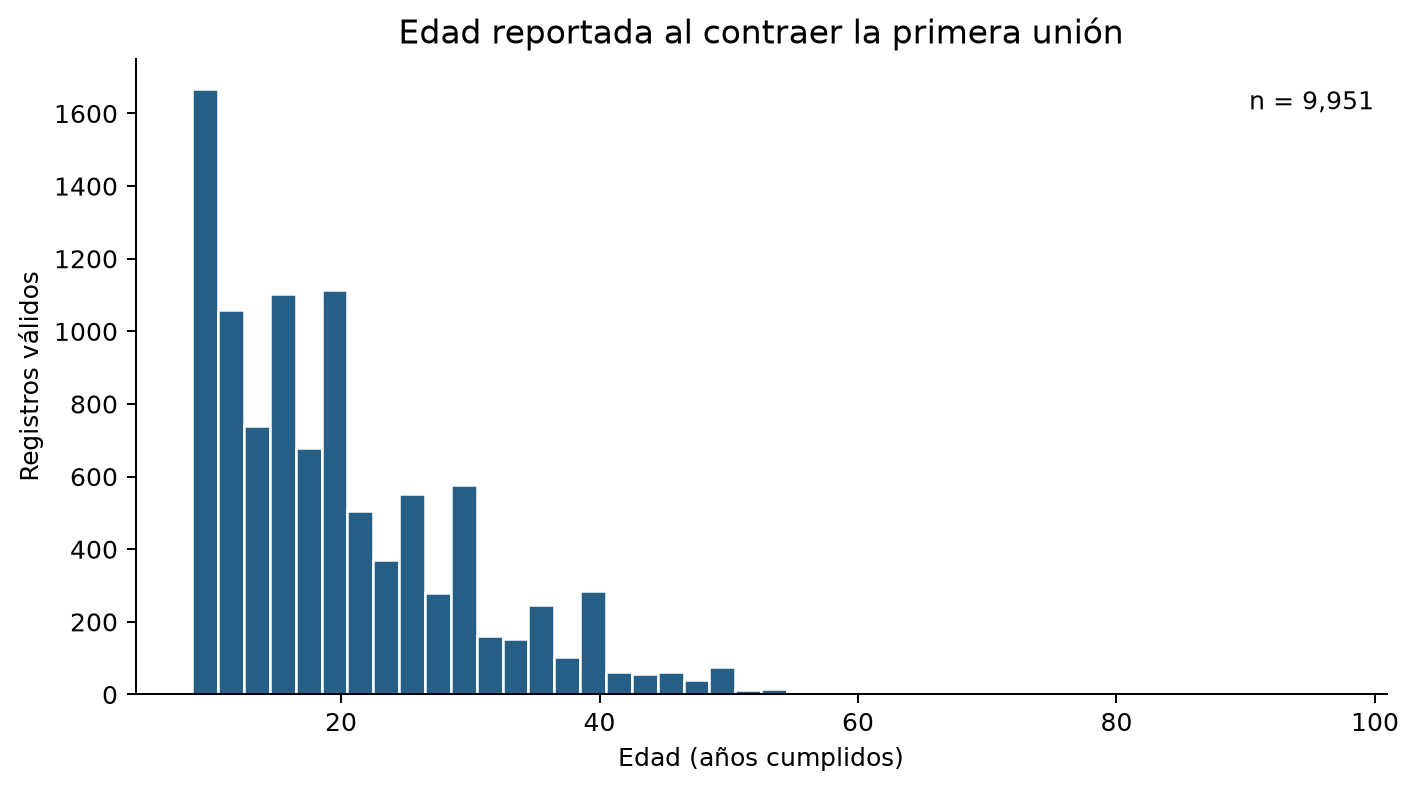

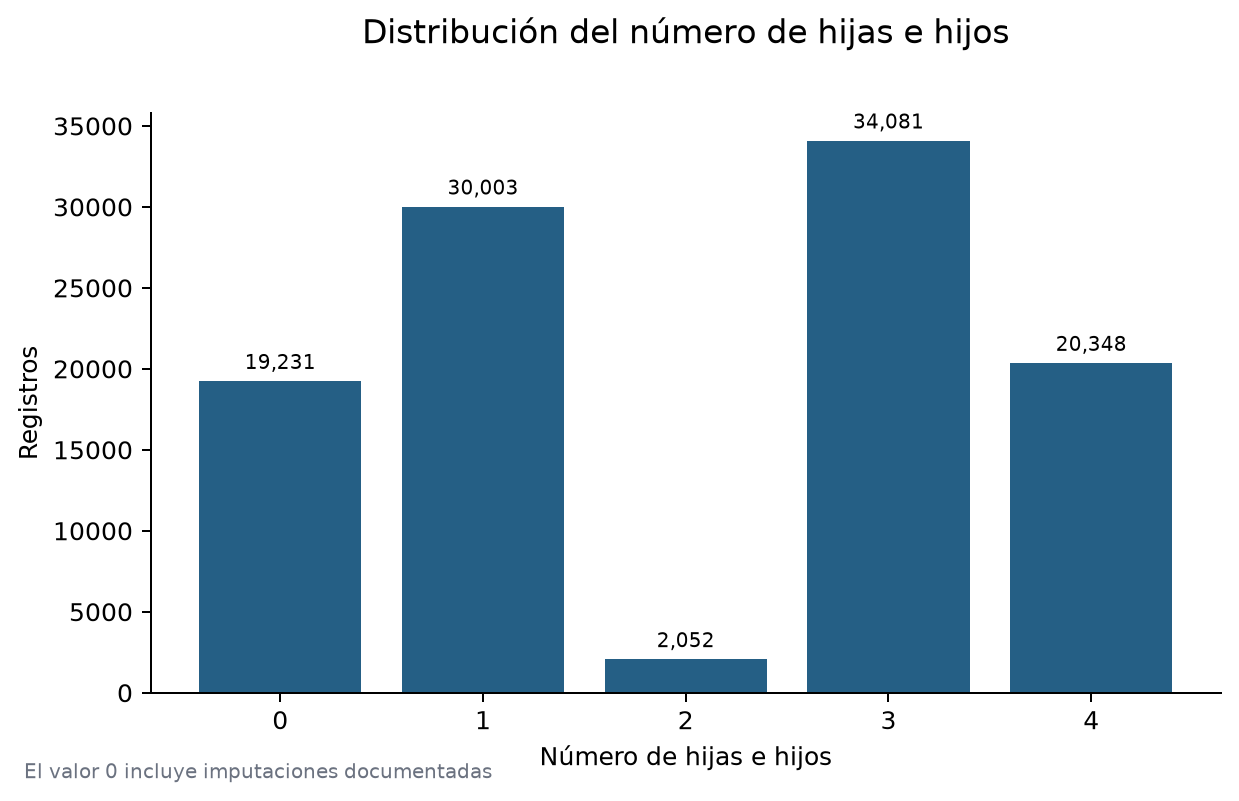

In [4]:
for nombre in ['02_distribucion_edad.png', '03_distribucion_hijos.png']:
    display(Image(filename=RUTA_FIGURAS / nombre, width=850))

El histograma de edad tiene una cola hacia las edades más altas. Por eso también revisamos la mediana y los cuantiles. En la gráfica de hijos, la barra de cero incluye los valores que se rellenaron durante la limpieza. Ambas gráficas usan frecuencias de la muestra sin ponderar.